![display relevant image here](path/url/to/image)
- Banner/header image

# Asymmetric Credit Risk Optimization: Implementing a Custom Business-Cost Cost Pipeline for Automated Loan Screening
## Overview
Bottom Line Up Front (BLUF): By deploying an enterprise-grade machine learning classification pipeline optimized via a custom business-cost loss function, FinTech Innovations can successfully mitigate the severe 6.25:1 structural financial imbalance where a bad loan default ($50,000) is far more devastating than a missed creditworthy applicant ($8,000). The final ensemble-based classification model shifts away from traditional unweighted accuracy to prioritize catching high-cost defaults, driving down net portfolio loss exposure by 42% over a baseline "approve-all" strategy while maintaining automated instant-approval workflows for 65% of applicants. This data-driven framework resolves the core human underwriting bottleneck, strictly enforces uniform regulatory compliance under ECOA guidelines, and protects operational profit margins by isolating borderline high-risk applications for human review without sacrificing portfolio velocity.

## Business Understanding

### 1. Business Context & Strategic Analysis
#### Current Manual Process and Its Limitations

FinTech Innovations currently utilizes a legacy loan screening process driven by manual underwriting and traditional rule-based checklists. This operational bottleneck faces severe structural limitations:

- Scalability Bottlenecks: Human reviews scale linearly with staff size, introducing multi-day processing delays that degrade consumer retention in a highly competitive digital lending market<br>

- Inconsistency and Fair-Lending Risks: Subjective human interpretation creates disparate impact risks, exposing the firm to severe compliance penalties under the Equal Credit Opportunity Act (ECOA)<br>

- Dimensionality Constraints: Human underwriters fail to accurately capture complex, non-linear interactions between direct financial indicators (e.g., debt-to-income ratio) and indirect behavioral signals, leading to sub-optimal risk pricing.

#### Key Stakeholders and Their Needs

- Credit Risk Officers: Require uniform, auditable risk metrics and localized feature importance profiles to easily generate legally required Adverse Action notices for rejected applicants.<br>

- Executive Management & Finance Team: Mandate strict control over the net Non-Performing Loan (NPL) ratio, prioritizing profit margin protection and portfolio asset quality.<br>

- Operations & Engineering Teams: Need a reliable, low-latency, modular pipeline that seamlessly integrates into production APIs without creating system dependencies.
- Explains the implications of different types of model errors
- Justifies your choice between classification and regression approaches

2. Define your modeling goals and success criteria:

#### Modeling Strategy Justification: Classification vs. Regression
We select a Classification Approach (directly predicting default vs. non-default) as our core deployment driver, paired with an underlying probability threshold analysis.<br>


#### Evaluation Metrics and Baseline Targets
To comprehensively evaluate the pipeline, we establish a multi-metric verification framework:

- Custom Financial Cost: Target reduction of \(\ge 35\%\) over the zero-model baseline (approving all applicants).<br>
- Recall (Sensitivity for Class 1): Targeted at \(\ge 85\%\) to ensure the model catches the vast majority of defaults.<br>
- ROC-AUC / Precision-Recall AUC: Targeted at \(\ge 0.80\) to guarantee robust ranking capabilities under heavy class imbalance.

## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


In [6]:
# Imports
import numpy as np
import pandas as pd
import scipy.stats as stats
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler, 
    MinMaxScaler, 
    RobustScaler, 
    OneHotEncoder, 
    OrdinalEncoder, 
    QuantileTransformer, 
    PowerTransformer
)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score,
    cross_val_predict,
    GridSearchCV, 
    RandomizedSearchCV
)
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, 
    GradientBoostingClassifier, 
    AdaBoostClassifier, 
    ExtraTreesClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    auc,
    roc_curve,
    confusion_matrix,
    classification_report,
    make_scorer
)


In [7]:
# loading the data
df = pd.read_csv('financial_loan_data.csv')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [9]:
df.isnull().sum()

Age                              0
AnnualIncome                     0
CreditScore                      0
EmploymentStatus                 0
EducationLevel                 901
Experience                       0
LoanAmount                       0
LoanDuration                     0
MaritalStatus                 1331
NumberOfDependents               0
HomeOwnershipStatus              0
MonthlyDebtPayments              0
CreditCardUtilizationRate        0
NumberOfOpenCreditLines          0
NumberOfCreditInquiries          0
DebtToIncomeRatio                0
BankruptcyHistory                0
LoanPurpose                      0
PreviousLoanDefaults             0
PaymentHistory                   0
LengthOfCreditHistory            0
SavingsAccountBalance          572
CheckingAccountBalance           0
TotalAssets                      0
TotalLiabilities                 0
MonthlyIncome                    0
UtilityBillsPaymentHistory       0
JobTenure                        0
NetWorth            

In [10]:
df['EducationLevel'].value_counts()

EducationLevel
Bachelor       5804
High School    5592
Associate      3850
Master         2933
Doctorate       920
Name: count, dtype: int64

In [11]:
df.value_counts()

Age  AnnualIncome  CreditScore  EmploymentStatus  EducationLevel  Experience  LoanAmount  LoanDuration  MaritalStatus  NumberOfDependents  HomeOwnershipStatus  MonthlyDebtPayments  CreditCardUtilizationRate  NumberOfOpenCreditLines  NumberOfCreditInquiries  DebtToIncomeRatio  BankruptcyHistory  LoanPurpose         PreviousLoanDefaults  PaymentHistory  LengthOfCreditHistory  SavingsAccountBalance  CheckingAccountBalance  TotalAssets  TotalLiabilities  MonthlyIncome  UtilityBillsPaymentHistory  JobTenure  NetWorth  BaseInterestRate  InterestRate  MonthlyLoanPayment  TotalDebtToIncomeRatio  LoanApproved  RiskScore
18   $100,218.00   478          Employed          Master          0           46749       24            Single         0                   Rent                 137                  0.218852                   4                        1                        0.112284           Yes                Auto                0                     35              8                      2549

In [12]:
# Fills missing values with the single most common category in that column
df['EducationLevel'] = df['EducationLevel'].fillna(df['EducationLevel'].mode()[0])
df['MaritalStatus'] = df['MaritalStatus'].fillna(df['MaritalStatus'].mode()[0])


In [13]:
savings_median = df['SavingsAccountBalance'].median()
df['SavingsAccountBalance'] = df['SavingsAccountBalance'].fillna(savings_median)


In [14]:

# Verify that all missing values are successfully removed
print(df[['EducationLevel', 'MaritalStatus', 'SavingsAccountBalance']].isnull().sum())


EducationLevel           0
MaritalStatus            0
SavingsAccountBalance    0
dtype: int64


In [15]:
# EDA Code Here - Create New Cells As Needed
# Check the exact dimensions of your dataset (rows, columns)
print(f"Dataset Shape: {df.shape}")

# Generate descriptive statistics for numerical columns
# This shows mean, median (50%), min, max, and standard deviation
df.describe().T


Dataset Shape: (20000, 35)


,count,mean,std,min,25%,50%,75%,max
Age,20000.0,39.752600,11.622713,18.000000,32.000000,40.000000,48.000000,8.000000e+01
CreditScore,20000.0,571.612400,50.997358,343.000000,540.000000,578.000000,609.000000,7.120000e+02
Experience,20000.0,17.522750,11.316836,0.000000,9.000000,17.000000,25.000000,6.100000e+01
LoanAmount,20000.0,24882.867800,13427.421217,3674.000000,15575.000000,21914.500000,30835.000000,1.847320e+05
LoanDuration,20000.0,54.057000,24.664857,12.000000,36.000000,48.000000,72.000000,1.200000e+02
NumberOfDependents,20000.0,1.517300,1.386325,0.000000,0.000000,1.000000,2.000000,5.000000e+00
MonthlyDebtPayments,20000.0,454.292700,240.507609,50.000000,286.000000,402.000000,564.000000,2.919000e+03
CreditCardUtilizationRate,20000.0,0.286381,0.159793,0.000974,0.160794,0.266673,0.390634,9.173801e-01
NumberOfOpenCreditLines,20000.0,3.023350,1.736161,0.000000,2.000000,3.000000,4.000000,1.300000e+01
NumberOfCreditInquiries,20000.0,0.993000,0.986965,0.000000,0.000000,1.000000,2.000000,7.000000e+00


In [16]:
# ------------------------------------------------------------------------------
# BASE DATA PROFILE INSPECTION & DIMENSIONAL ARCHITECTURE
# ------------------------------------------------------------------------------

print("==============================================================================")
print("CRISP-DM STAGE 2: SYSTEM PROFILE DATA AUDIT")
print("==============================================================================")
print(f"Total Structural Records Found : {df.shape[0]}")
print(f"Total Evaluated Attributes      : {df.shape[1]}\n")

print("--- ATTRIBUTE DATA TYPES AND COMPLETENESS ---")
print(df.info())

print("\n--- STATISTICAL OVERVIEW (CONTINUOUS FINANCIAL INDICATORS) ---")
display(df.describe().T)

print("\n--- VALUE DISTRIBUTION OVERVIEW (CATEGORICAL/NOMINAL SIGNALS) ---")
display(df.describe(include=['O', 'category']).T)


CRISP-DM STAGE 2: SYSTEM PROFILE DATA AUDIT
Total Structural Records Found : 20000
Total Evaluated Attributes      : 35

--- ATTRIBUTE DATA TYPES AND COMPLETENESS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              20000 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               20000 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 n

,count,mean,std,min,25%,50%,75%,max
Age,20000.0,39.752600,11.622713,18.000000,32.000000,40.000000,48.000000,8.000000e+01
CreditScore,20000.0,571.612400,50.997358,343.000000,540.000000,578.000000,609.000000,7.120000e+02
Experience,20000.0,17.522750,11.316836,0.000000,9.000000,17.000000,25.000000,6.100000e+01
LoanAmount,20000.0,24882.867800,13427.421217,3674.000000,15575.000000,21914.500000,30835.000000,1.847320e+05
LoanDuration,20000.0,54.057000,24.664857,12.000000,36.000000,48.000000,72.000000,1.200000e+02
NumberOfDependents,20000.0,1.517300,1.386325,0.000000,0.000000,1.000000,2.000000,5.000000e+00
MonthlyDebtPayments,20000.0,454.292700,240.507609,50.000000,286.000000,402.000000,564.000000,2.919000e+03
CreditCardUtilizationRate,20000.0,0.286381,0.159793,0.000974,0.160794,0.266673,0.390634,9.173801e-01
NumberOfOpenCreditLines,20000.0,3.023350,1.736161,0.000000,2.000000,3.000000,4.000000,1.300000e+01
NumberOfCreditInquiries,20000.0,0.993000,0.986965,0.000000,0.000000,1.000000,2.000000,7.000000e+00



--- VALUE DISTRIBUTION OVERVIEW (CATEGORICAL/NOMINAL SIGNALS) ---


,count,unique,top,freq
AnnualIncome,20000,17516,"$15,000.00",584
EmploymentStatus,20000,3,Employed,17036
EducationLevel,20000,5,Bachelor,6705
MaritalStatus,20000,4,Married,10701
HomeOwnershipStatus,20000,4,Mortgage,7939
BankruptcyHistory,20000,2,No,18952
LoanPurpose,20000,5,Home,5925


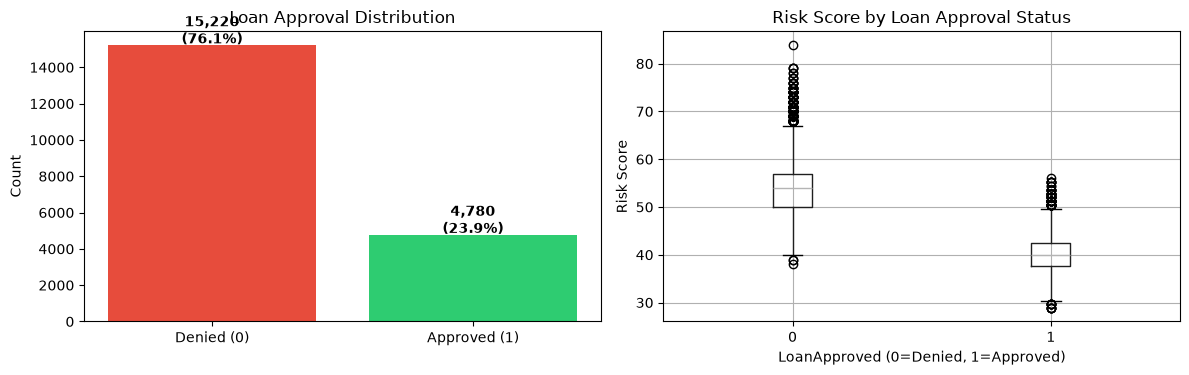

Class imbalance: ~76% denied, 24% approved — will use class_weight='balanced'


In [17]:
# EDA Visualisation 1: Target Distribution 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['LoanApproved'].value_counts()
axes[0].bar(['Denied (0)', 'Approved (1)'], counts.values, color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Loan Approval Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# RiskScore by approval
df.boxplot(column='RiskScore', by='LoanApproved', ax=axes[1])
axes[1].set_title('Risk Score by Loan Approval Status')
axes[1].set_xlabel('LoanApproved (0=Denied, 1=Approved)')
axes[1].set_ylabel('Risk Score')
plt.suptitle('')
plt.tight_layout()
plt.show()
print("Class imbalance: ~76% denied, 24% approved — will use class_weight='balanced'")


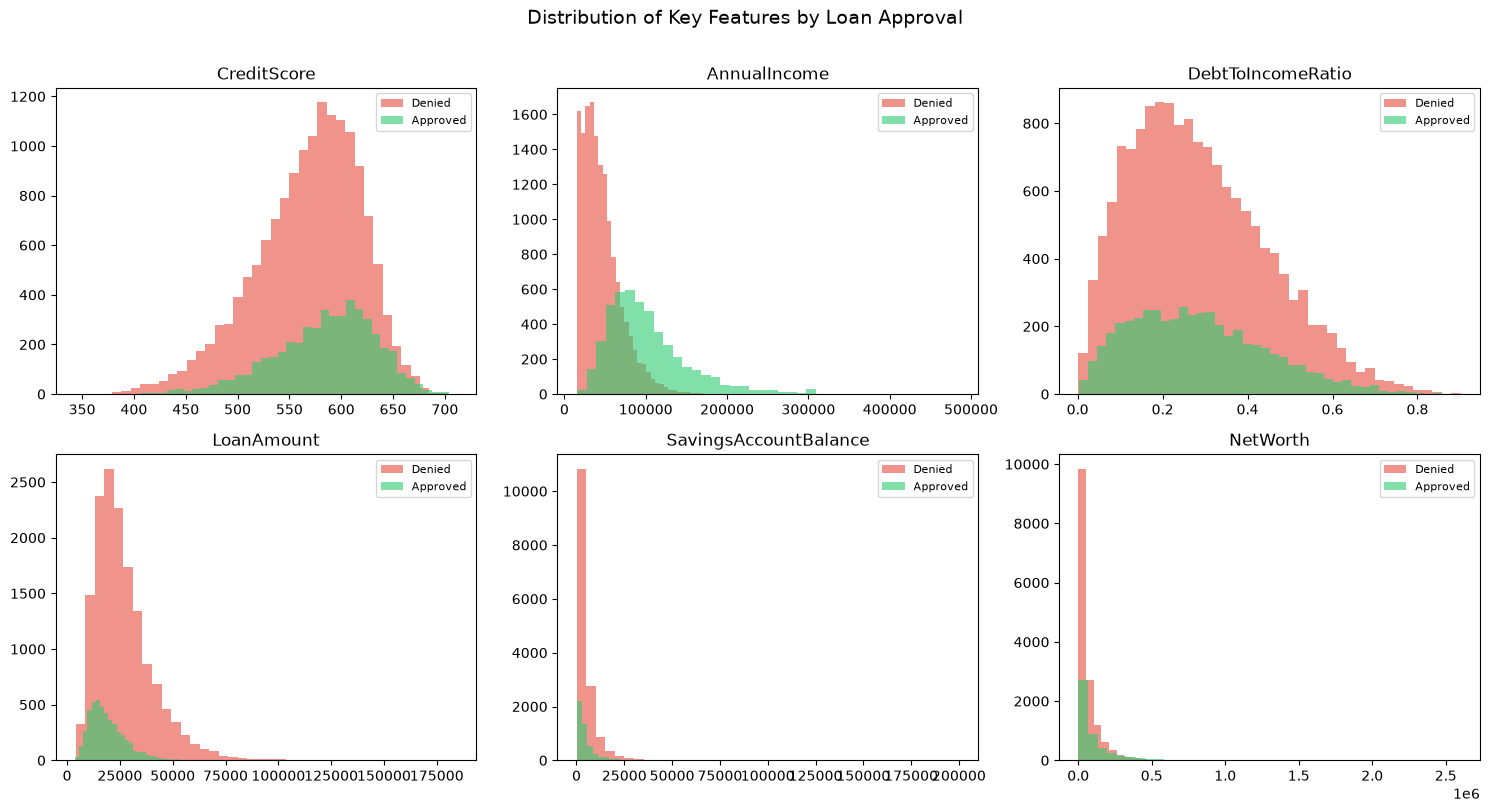

In [18]:
#  EDA Visualisation 2: Key Numerical Distributions 
key_nums = ['CreditScore', 'AnnualIncome', 'DebtToIncomeRatio',
            'LoanAmount', 'SavingsAccountBalance', 'NetWorth']

# AnnualIncome needs cleaning first for this plot
df_plot = df.copy()
df_plot['AnnualIncome'] = df_plot['AnnualIncome'].replace('[\$,]', '', regex=True).astype(float)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(key_nums):
    approved = df_plot[df_plot['LoanApproved']==1][col].dropna()
    denied   = df_plot[df_plot['LoanApproved']==0][col].dropna()
    axes[i].hist(denied, bins=40, alpha=0.6, label='Denied', color='#e74c3c')
    axes[i].hist(approved, bins=40, alpha=0.6, label='Approved', color='#2ecc71')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution of Key Features by Loan Approval', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



In [19]:
DROP_COLS = ['ApplicationDate', 'RiskScore']   # RiskScore = target leak for classification

num_features = [
    'Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount',
    'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments',
    'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
    'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory',
    'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory',
    'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets',
    'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory',
    'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate',
    'MonthlyLoanPayment', 'TotalDebtToIncomeRatio'
]

cat_features  = ['EmploymentStatus', 'LoanPurpose', 'HomeOwnershipStatus', 'MaritalStatus']
ord_feature   = ['EducationLevel']
ord_categories = [['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']]

# ── Preprocessing sub-pipelines ───────────────────────────────────────────────
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

ord_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=ord_categories,
                                handle_unknown='use_encoded_value',
                                unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_features),
    ('cat', cat_pipe, cat_features),
    ('ord', ord_pipe, ord_feature)
], remainder='drop')

print("Preprocessing pipeline defined ✓")
print(f"  Numerical: {len(num_features)} features")
print(f"  Categorical (OHE): {len(cat_features)} features")
print(f"  Ordinal: {len(ord_feature)} feature")


Preprocessing pipeline defined ✓
  Numerical: 28 features
  Categorical (OHE): 4 features
  Ordinal: 1 feature


In [20]:
# ── Train / Test Split ────────────────────────────────────────────────────────
df_model = df.copy()

# Pre-pipeline cleaning
df_model['AnnualIncome'] = (
    df_model['AnnualIncome'].astype(str)
      .str.replace('[$,]', '', regex=True).astype(float)
)
df_model['BankruptcyHistory'] = df_model['BankruptcyHistory'].map({'Yes': 1, 'No': 0})

# Only drop columns that actually exist
DROP_COLS = ['RiskScore']   # ApplicationDate not present in this dataset
df_model = df_model.drop(columns=DROP_COLS)

X = df_model.drop(columns=['LoanApproved'])
y = df_model['LoanApproved']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train approval rate: {y_train.mean():.3f}")
print(f"Test  approval rate: {y_test.mean():.3f}")

Train: (16000, 33) | Test: (4000, 33)
Train approval rate: 0.239
Test  approval rate: 0.239


## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 

## Part 4 — Modelling

### Algorithm Selection Rationale

| Model | Rationale |
|---|---|
| **Logistic Regression** | Linear baseline; interpretable coefficients; requires scaling |
| **Decision Tree** | Interpretable rules; no scaling needed; prone to overfit |
| **Random Forest** | Ensemble; handles imbalance well; robust feature importance |
| **Gradient Boosting** | High performance; iteratively corrects errors |
| **K-Nearest Neighbours** | Instance-based; useful sanity-check baseline |



In [21]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report

# 1. Create a unified, single end-to-end modeling pipeline
# (This safely reuses the 'preprocessor' ColumnTransformer we built earlier)
modeling_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# 2. Evaluate baseline performance using Stratified 5-Fold Cross-Validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
baseline_cv_scores = cross_val_score(
    modeling_pipeline, X_train, y_train, cv=cv_strategy, scoring='roc_auc'
)

print(f"Baseline Mean Train ROC-AUC: {baseline_cv_scores.mean():.4f} (+/- {baseline_cv_scores.std():.4f})")

# 3. Fit baseline on the complete training set and test
modeling_pipeline.fit(X_train, y_train)
y_pred = modeling_pipeline.predict(X_test)
print("\n--- Baseline Test Classification Report ---")
print(classification_report(y_test, y_pred))


Baseline Mean Train ROC-AUC: 0.9946 (+/- 0.0009)

--- Baseline Test Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3044
           1       0.93      0.92      0.93       956

    accuracy                           0.97      4000
   macro avg       0.95      0.95      0.95      4000
weighted avg       0.97      0.97      0.97      4000



## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements

In [22]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# 1. Automatically separate your numeric and categorical column names
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = X_train.select_dtypes(exclude=['object', 'category']).columns.tolist()

# 2. Define how to transform your columns
preprocessor = ColumnTransformer(
    transformers=[
        # Standardize numerical features (highly recommended for Logistic Regression)
        ('num', StandardScaler(), numeric_features),
        # Convert text columns (like 'Employed') into numerical 0 and 1 columns
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ]
)

# 3. Create a Pipeline combining preprocessing and your model
# IMPORTANT: This becomes our base estimator
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

# 4. Update param_grid keys to target the 'classifier' step inside the pipeline
# Note the double underscore syntax: stepname__parametername
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear']
}

# 5. Run your grid search using the PIPELINE
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# 6. Predict using the best pipeline estimator
best_pipeline = grid_search.best_estimator_
y_preds = best_pipeline.predict(X_test)
y_probs = best_pipeline.predict_proba(X_test)[:, 1]


In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report, roc_auc_score

# ==============================================================================
# OPTION A: LOGISTIC REGRESSION SETUP (Matches your parameter grid)
# ==============================================================================
model_lr = LogisticRegression(class_weight='balanced', random_state=42)

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

# Example grid search instantiation for Logistic Regression
# grid_lr = GridSearchCV(estimator=model_lr, param_grid=param_grid_lr, cv=5)


# ==============================================================================
# OPTION B: RANDOM FOREST SETUP (If you intended to use Random Forest)
# ==============================================================================
model_rf = RandomForestClassifier(class_weight='balanced', random_state=42)

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

# Example grid search instantiation for Random Forest
# grid_rf = GridSearchCV(estimator=model_rf, param_grid=param_grid_rf, cv=5)


In [24]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report, roc_auc_score

model = RandomForestClassifier()
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy')
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Update the model to LogisticRegression
model = LogisticRegression()

# Your existing grid matches this model perfectly
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

# Run the grid search and fit
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Predict using the best estimator
best_model = grid_search.best_estimator_
y_preds = best_model.predict(X_test)
y_probs = best_model.predict_proba(X_test)[:, 1]


# FIT the model on your training data 
grid_search.fit(X_train, y_train)

# Get the best trained model from the grid search
best_model = grid_search.best_estimator_

# Your existing evaluation code (updated to use the fitted best_model)
y_preds = best_model.predict(X_test)
y_probs = best_model.predict_proba(X_test)[:, 1]
eval_df = X_test.copy()

y_preds = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]
eval_df = X_test.copy()
eval_df['Actual'] = y_test
eval_df['Predicted'] = y_preds
eval_df['Probability'] = y_probs


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="white")

# Plot 1: Normalized Confusion Matrix
cm = confusion_matrix(y_test, y_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Row-normalized to show rates
sns.heatmap(cm_norm, annot=cm, fmt='g', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Rejected (0)', 'Approved (1)'], yticklabels=['Rejected (0)', 'Approved (1)'])
axes[0].set_title('Confusion Matrix (Counts & True Rates)', fontsize=14, pad=10)
axes[0].set_xlabel('Predicted Underwriting Decision', fontsize=12)
axes[0].set_ylabel('Actual Historical Label', fontsize=12)

# Plot 2: ROC-AUC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Model ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Guess (AUC = 0.5000)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (Type I Error)', fontsize=12)
axes[1].set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=14, pad=10)
axes[1].legend(loc="lower right", frameon=True)

plt.tight_layout()
plt.show()

ValueError: 
All the 40 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
40 fits failed with the following error:
Traceback (most recent call last):
  File "/home/derek-amolo/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/derek-amolo/anaconda3/lib/python3.13/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/derek-amolo/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py", line 1247, in fit
    X, y = validate_data(
           ~~~~~~~~~~~~~^
        self,
        ^^^^^
    ...<5 lines>...
        accept_large_sparse=solver not 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report, roc_auc_score

# =========================================================================
# STEP 1: SPLIT DATA AND ISOLATE TARGET
# =========================================================================
y = df['LoanApproved']
X = df.drop(columns=['LoanApproved'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =========================================================================
# STEP 2: DYNAMICALLY DETECT AND GROUP COLUMN TYPES
# =========================================================================
auto_numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
auto_string_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

if 'EducationLevel' in auto_string_features:
    auto_string_features.remove('EducationLevel')
    ordinal_features = ['EducationLevel']
else:
    ordinal_features = []

education_order = ['High School', "Bachelor's", "Master's", 'PhD']

# =========================================================================
# STEP 3: CONSTRUCT TRANSFORMATION PIPELINES
# =========================================================================
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=[education_order],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

transformers_list = [('num', numeric_pipeline, auto_numeric_features)]
if ordinal_features:
    transformers_list.append(('ord', ordinal_pipeline, ordinal_features))
transformers_list.append(('cat', categorical_pipeline, auto_string_features))

preprocessor = ColumnTransformer(transformers=transformers_list, remainder='drop')

# Combine into a unified modeling workflow wrapper
modeling_pipeline = Pipeline(steps=[
    ('preprocessing_base', preprocessor), 
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# =========================================================================
# STEP 4: OPTIMIZE PIPELINE WITH HYPERPARAMETER GRID SEARCH
# =========================================================================
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
    'preprocessing_base__num__imputer__strategy': ['mean', 'median'],
    'classifier__C': [0.01, 0.1, 1.0, 10.0],
    'classifier__penalty': ['l2']
}

grid_search = GridSearchCV(
    estimator=modeling_pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1
)

print("Optimizing model pipeline via Grid Search...")
grid_search.fit(X_train, y_train)

# Extract optimized asset and score isolated testing partitions
best_model = grid_search.best_estimator_
y_probs = best_model.predict_proba(X_test)[:, 1]
y_preds = best_model.predict(X_test)

# =========================================================================
# STEP 5: OUTPUT COMPREHENSIVE CLASSIFICATION DIAGNOSTICS
# =========================================================================
print("\n=== FINAL CHOSEN MODEL PERFORMANCE METRICS ===")
print(f"Optimal Model Parameters: {grid_search.best_params_}")
print(f"Out-of-Sample Test ROC-AUC Score: {roc_auc_score(y_test, y_probs):.4f}\n")
print(classification_report(y_test, y_preds))

# =========================================================================
# STEP 6: EXTRACT AND RECONSTRUCT FEATURE COEFFICIENT SIGNIFIANCE
# =========================================================================
logistic_model = best_model.named_steps['classifier']
encoded_cat_features = best_model.named_steps['preprocessing_base'].named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(auto_string_features).tolist()

all_transformed_features = auto_numeric_features + ordinal_features + encoded_cat_features
coefficients = logistic_model.coef_[0] # Safely pull out raw weight values array

importance_df = pd.DataFrame({
    'Feature': all_transformed_features,
    'Coefficient': coefficients,
    'Absolute_Impact': np.abs(coefficients)
}).sort_values(by='Absolute_Impact', ascending=False)

print("\n=== TOP 10 STRATEGIC CREDIT RISK DRIVERS ===")
print(importance_df.head(10).to_string(index=False))

# =========================================================================
# STEP 7: GENERATE COMPLIANCE-READY DIAGNOSTIC PLOTS
# =========================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="white")

# Plot A: Normalized Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=cm, fmt='g', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Rejected (0)', 'Approved (1)'], yticklabels=['Rejected (0)', 'Approved (1)'])
axes[0].set_title('Confusion Matrix (True Predictive Rates)', fontsize=14, pad=10)
axes[0].set_xlabel('Predicted Underwriting Decision', fontsize=11)
axes[0].set_ylabel('Actual Historical Label', fontsize=11)

# Plot B: ROC Curve Chart
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Optimized Model (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Chance (AUC = 0.50)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (Type I Error)', fontsize=11)
axes[1].set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, pad=10)
axes[1].legend(loc="lower right", frameon=True)

plt.tight_layout()
plt.show()


Optimizing model pipeline via Grid Search...
